## Question 1 avec invgamma comme prior

In [1]:
import numpy as np
from q1_b import simulate_lognormal_sum, wasserstein_1d, reject_abc

In [2]:


seed_value = 42
main_rng = np.random.default_rng(seed_value)
    
L_true = 10
mu_true = 0.0
sigma_true = 0.3
n_obs = 200  
    
print("Generating strictly defined observational data...")
Y_obs = simulate_lognormal_sum(n_obs, L_true, mu_true, sigma_true, rng=main_rng)

##### epsilon and the prior affect the result ###
    
epsilon_val = 0.5 
    
# NOUVEAUX PARAMÈTRES (a, b, kappa au lieu de s, t)
prior_configs = [
    {"a": 3.0, "b": 0.2, "kappa": 5.0, "name": "Well-calibrated"},
    {"a": 0.1, "b": 0.1, "kappa": 100.0, "name": "Highly diffuse (Efficiency drop)"},
    {"a": 100.0, "b": 100.0, "kappa": 0.01, "name": "Highly concentrated (Prior bias risk)"}
]
    
print(f"\n--- Rejection-ABC Empirical Results (Target: mu={mu_true}, sigma={sigma_true}) ---")
for config in prior_configs:
    print(f"\nEvaluating '{config['name']}' prior specification (a={config['a']}, b={config['b']}, kappa={config['kappa']}):")
        
    # L'appel à la fonction mise à jour
    samples, acc_rate = reject_abc(
        Y_obs, L_true, config['a'], config['b'], config['kappa'], epsilon_val, num_samples=50, rng=main_rng
    )
        
    print(f"  -> Acceptance Rate : {acc_rate:.4%}")
        
    if len(samples) > 0:
        mu_est = np.mean(samples[:, 0])
        sigma_est = np.mean(samples[:, 1])
        print(f"  -> Estimated mu    : {mu_est:.4f}")
        print(f"  -> Estimated sigma : {sigma_est:.4f}")
    else:
        print("  -> Estimated mu    : N/A (0 samples accepted)")
        print("  -> Estimated sigma : N/A (0 samples accepted)")

Generating strictly defined observational data...

--- Rejection-ABC Empirical Results (Target: mu=0.0, sigma=0.3) ---

Evaluating 'Well-calibrated' prior specification (a=3.0, b=0.2, kappa=5.0):
  -> Acceptance Rate : 4.9652%
  -> Estimated mu    : -0.0053
  -> Estimated sigma : 0.2620

Evaluating 'Highly diffuse (Efficiency drop)' prior specification (a=0.1, b=0.1, kappa=100.0):


c:\Users\33783\OneDrive - GENES\Documents\Travail\ENSAE\2A\S2\6.Simulation & Monte Carlo\Projet MC\Likelihood-free-inference-and-sums-of-log-normal-variates\src\q1_b.py:12: RuntimeWarning: overflow encountered in exp
  Y = np.sum(np.exp(X), axis=1)
c:\Users\33783\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\33783\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


    [!] Computational limit reached (10000 iterations). Only 3 samples accepted.
  -> Acceptance Rate : 0.0300%
  -> Estimated mu    : -0.0497
  -> Estimated sigma : 0.3399

Evaluating 'Highly concentrated (Prior bias risk)' prior specification (a=100.0, b=100.0, kappa=0.01):
    [!] Computational limit reached (10000 iterations). Only 0 samples accepted.
  -> Acceptance Rate : 0.0000%
  -> Estimated mu    : N/A (0 samples accepted)
  -> Estimated sigma : N/A (0 samples accepted)


c:\Users\33783\OneDrive - GENES\Documents\Travail\ENSAE\2A\S2\6.Simulation & Monte Carlo\Projet MC\Likelihood-free-inference-and-sums-of-log-normal-variates\src\q1_b.py:12: RuntimeWarning: overflow encountered in exp
  Y = np.sum(np.exp(X), axis=1)
c:\Users\33783\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
c:\Users\33783\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


    [!] Computational limit reached (200000 iterations). Only 133 samples accepted.
    [!] Computational limit reached (200000 iterations). Only 0 samples accepted.
Saved: fig1_prior_impact.png
ε=0.10  acc=0.1826%  μ̂=-0.0141  σ̂=0.2926
ε=0.30  acc=2.6434%  μ̂=-0.0091  σ̂=0.2717
ε=0.50  acc=5.9970%  μ̂=-0.0103  σ̂=0.2627
ε=1.00  acc=12.9618%  μ̂=-0.0147  σ̂=0.2703
ε=2.00  acc=24.8447%  μ̂=-0.0141  σ̂=0.2691
Saved: fig2_epsilon_impact.png


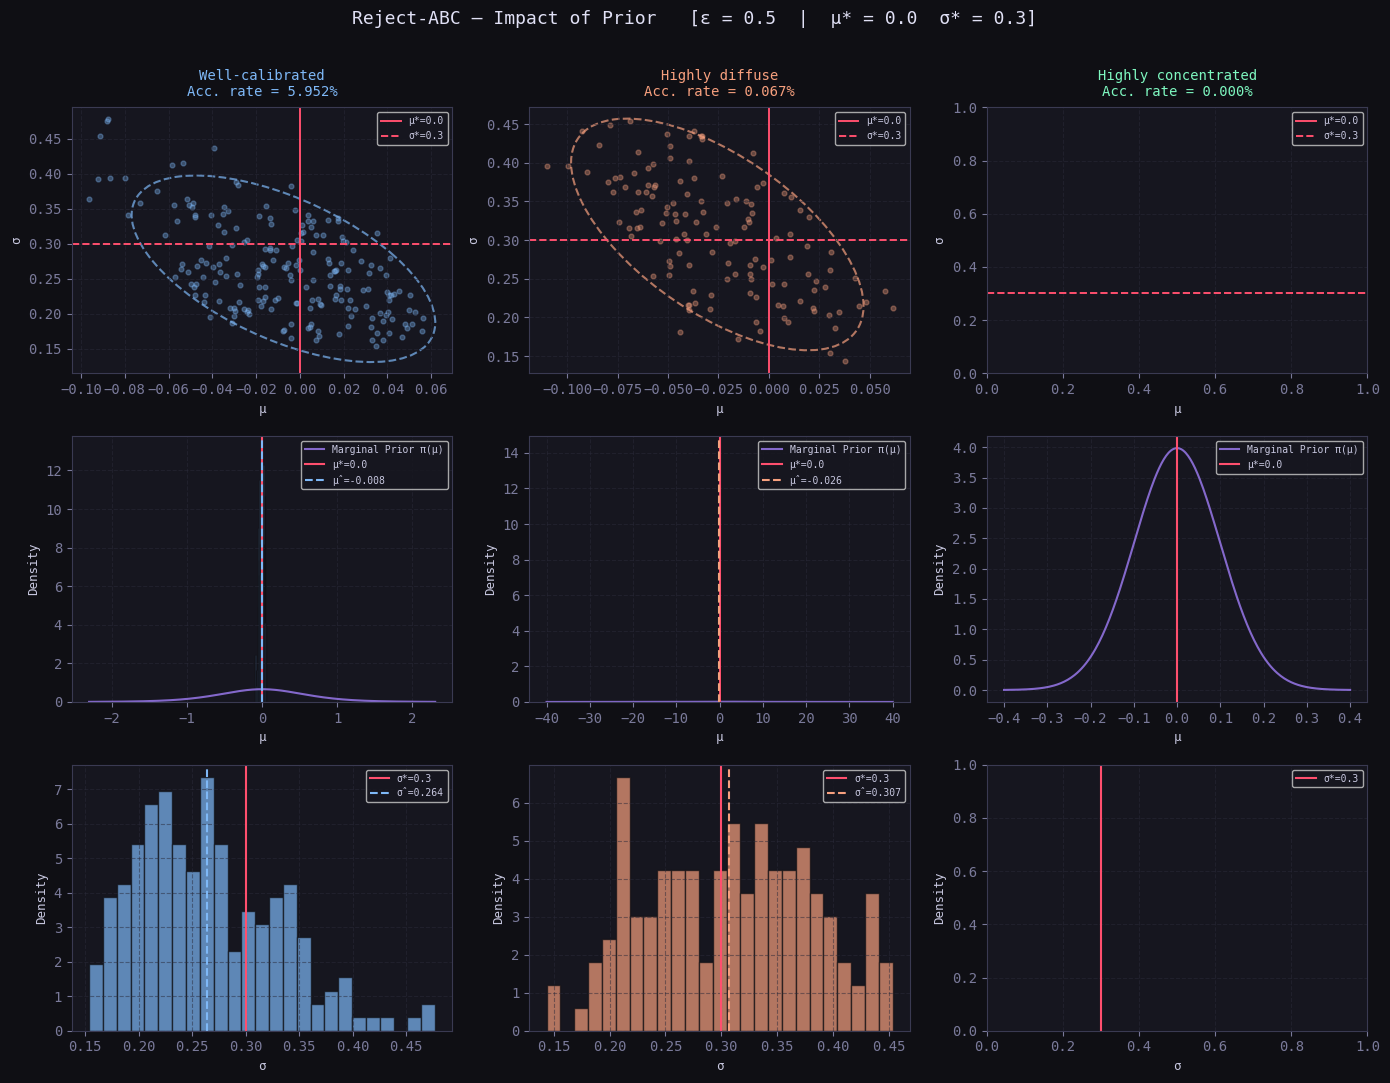

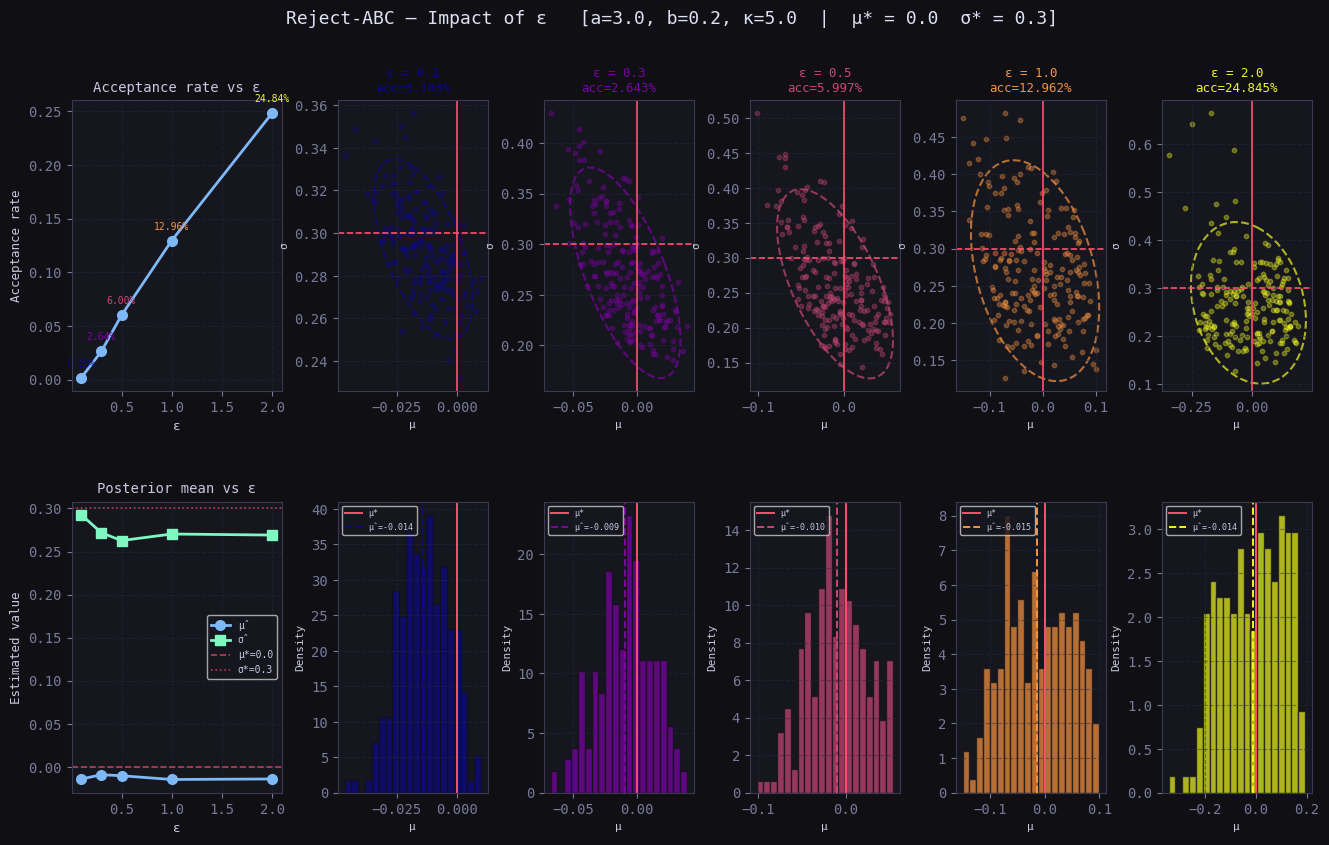

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import scipy.stats as stats
from q1_b import simulate_lognormal_sum, wasserstein_1d, reject_abc

# ─────────────────────────────────────────────
#  GLOBAL SEED & TRUE PARAMETERS
# ─────────────────────────────────────────────
SEED      = 42
L_TRUE    = 10
MU_TRUE   = 0.0
SIGMA_TRUE = 0.3
N_OBS     = 200
N_SAMPLES = 200   # accepted samples per run (increase for smoother plots)

main_rng = np.random.default_rng(SEED)
Y_obs = simulate_lognormal_sum(N_OBS, L_TRUE, MU_TRUE, SIGMA_TRUE, rng=main_rng)

# ─────────────────────────────────────────────
#  STYLE
# ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f0f14",
    "axes.facecolor":   "#16161f",
    "axes.edgecolor":   "#3a3a52",
    "axes.labelcolor":  "#c8c8e0",
    "xtick.color":      "#7a7a9a",
    "ytick.color":      "#7a7a9a",
    "text.color":       "#c8c8e0",
    "grid.color":       "#2a2a3a",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.family":      "monospace",
    "axes.titlesize":   10,
    "axes.labelsize":   9,
})

ACCENT   = ["#7eb8f7", "#f7a07e", "#7ef7c0"]   # blue / orange / green
TRUE_CLR = "#ff4f6e"
PRIOR_CLR = "#a07ef7"

def plot_ellipse(ax, samples, color, n_std=2.0):
    if len(samples) < 3:
        return
    cov = np.cov(samples[:, 0], samples[:, 1])
    mean = samples.mean(axis=0)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(mean, width=w, height=h, angle=angle,
                  edgecolor=color, facecolor="none", lw=1.5, linestyle="--", alpha=0.7)
    ax.add_patch(ell)

# ═══════════════════════════════════════════════════════════════
#  FIGURE 1 — Impact of prior (a, b, kappa)   [epsilon fixed]
# ═══════════════════════════════════════════════════════════════
EPSILON_FIXED = 0.5
PRIOR_CONFIGS = [
    {"a": 3.0, "b": 0.2, "kappa": 5.0,  "name": "Well-calibrated"},
    {"a": 0.1, "b": 0.1, "kappa": 100.0, "name": "Highly diffuse"},
    {"a": 100.0, "b": 100.0, "kappa": 0.01, "name": "Highly concentrated"},
]

fig1, axes1 = plt.subplots(3, 3, figsize=(14, 11))
fig1.suptitle(
    f"Reject-ABC — Impact of Prior   [ε = {EPSILON_FIXED}  |  μ* = {MU_TRUE}  σ* = {SIGMA_TRUE}]",
    fontsize=13, color="#e0e0f5", y=0.98
)

for col, cfg in enumerate(PRIOR_CONFIGS):
    rng = np.random.default_rng(SEED + col)
    samples, acc_rate = reject_abc(
        Y_obs, L_TRUE, cfg["a"], cfg["b"], cfg["kappa"],
        EPSILON_FIXED, num_samples=N_SAMPLES,
        max_attempts=200_000, rng=rng
    )

    color = ACCENT[col]
    ax_sc  = axes1[0, col]
    ax_mu  = axes1[1, col]
    ax_sig = axes1[2, col]

    # ── column title ──
    ax_sc.set_title(
        f"{cfg['name']}\nAcc. rate = {acc_rate:.3%}",
        color=color, pad=8
    )

    # ── ROW 0 : scatter (mu, sigma) ──
    if len(samples) > 0:
        ax_sc.scatter(samples[:, 0], samples[:, 1],
                      alpha=0.35, s=12, color=color, rasterized=True)
        plot_ellipse(ax_sc, samples, color)
    ax_sc.axvline(MU_TRUE,    color=TRUE_CLR, lw=1.4, linestyle="-",  label=f"μ*={MU_TRUE}")
    ax_sc.axhline(SIGMA_TRUE, color=TRUE_CLR, lw=1.4, linestyle="--", label=f"σ*={SIGMA_TRUE}")
    ax_sc.set_xlabel("μ")
    ax_sc.set_ylabel("σ")
    ax_sc.legend(fontsize=7, loc="upper right")
    ax_sc.grid(True)

    # ── ROW 1 : histogram of mu ──
    if len(samples) > 0:
        ax_mu.hist(samples[:, 0], bins=25, density=True,
                   color=color, alpha=0.7, edgecolor="#0f0f14")
    
    # Overlay Marginal Prior for mu (Student-t distribution)
    df = 2 * cfg["a"]
    scale = np.sqrt(cfg["kappa"] * cfg["b"] / cfg["a"])
    x_range = np.linspace(-4 * scale, 4 * scale, 300)
    prior_pdf = stats.t.pdf(x_range, df=df, loc=0, scale=scale)
    ax_mu.plot(x_range, prior_pdf, color=PRIOR_CLR, lw=1.5, alpha=0.8, label="Marginal Prior π(μ)")
    
    ax_mu.axvline(MU_TRUE, color=TRUE_CLR, lw=1.5, label=f"μ*={MU_TRUE}")
    if len(samples) > 0:
        ax_mu.axvline(samples[:, 0].mean(), color=color, lw=1.5,
                      linestyle="--", label=f"μ̂={samples[:,0].mean():.3f}")
    ax_mu.set_xlabel("μ")
    ax_mu.set_ylabel("Density")
    ax_mu.legend(fontsize=7)
    ax_mu.grid(True)

    # ── ROW 2 : histogram of sigma ──
    if len(samples) > 0:
        ax_sig.hist(samples[:, 1], bins=25, density=True,
                    color=color, alpha=0.7, edgecolor="#0f0f14")
    ax_sig.axvline(SIGMA_TRUE, color=TRUE_CLR, lw=1.5, label=f"σ*={SIGMA_TRUE}")
    if len(samples) > 0:
        ax_sig.axvline(samples[:, 1].mean(), color=color, lw=1.5,
                       linestyle="--", label=f"σ̂={samples[:,1].mean():.3f}")
    ax_sig.set_xlabel("σ")
    ax_sig.set_ylabel("Density")
    ax_sig.legend(fontsize=7)
    ax_sig.grid(True)

fig1.tight_layout(rect=[0, 0, 1, 0.97])
fig1.savefig("fig1_prior_impact.png", dpi=150, bbox_inches="tight", facecolor=fig1.get_facecolor())
print("Saved: fig1_prior_impact.png")

# ═══════════════════════════════════════════════════════════════
#  FIGURE 2 — Impact of epsilon   [prior fixed: Well-calibrated]
# ═══════════════════════════════════════════════════════════════
A_FIXED = 3.0
B_FIXED = 0.2
KAPPA_FIXED = 5.0
EPSILONS = [0.1, 0.3, 0.5, 1.0, 2.0]

results_eps = []
for eps in EPSILONS:
    rng = np.random.default_rng(SEED + 100)
    samp, rate = reject_abc(
        Y_obs, L_TRUE, A_FIXED, B_FIXED, KAPPA_FIXED,
        eps, num_samples=N_SAMPLES,
        max_attempts=500_000, rng=rng
    )
    results_eps.append({
        "eps":      eps,
        "samples":  samp,
        "rate":     rate,
        "mu_hat":   samp[:, 0].mean() if len(samp) > 0 else np.nan,
        "sigma_hat": samp[:, 1].mean() if len(samp) > 0 else np.nan,
    })
    print(f"ε={eps:.2f}  acc={rate:.4%}  μ̂={results_eps[-1]['mu_hat']:.4f}  σ̂={results_eps[-1]['sigma_hat']:.4f}")

n_eps = len(EPSILONS)
cmap  = plt.cm.plasma
eps_colors = [cmap(i / (n_eps - 1)) for i in range(n_eps)]

fig2 = plt.figure(figsize=(16, 9))
fig2.suptitle(
    f"Reject-ABC — Impact of ε   [a={A_FIXED}, b={B_FIXED}, κ={KAPPA_FIXED}  |  μ* = {MU_TRUE}  σ* = {SIGMA_TRUE}]",
    fontsize=13, color="#e0e0f5"
)

gs = fig2.add_gridspec(2, n_eps + 1, hspace=0.38, wspace=0.35,
                        width_ratios=[1.4] + [1] * n_eps)

# ── left column: 3 summary curves (acceptance rate, mu_hat, sigma_hat) ──
ax_rate  = fig2.add_subplot(gs[0, 0])
ax_est   = fig2.add_subplot(gs[1, 0])

eps_vals  = [r["eps"]      for r in results_eps]
rates     = [r["rate"]     for r in results_eps]
mu_hats   = [r["mu_hat"]   for r in results_eps]
sig_hats  = [r["sigma_hat"] for r in results_eps]

# acceptance rate
ax_rate.plot(eps_vals, rates, "o-", color="#7eb8f7", lw=2, ms=7)
for i, (e, r) in enumerate(zip(eps_vals, rates)):
    ax_rate.annotate(f"{r:.2%}", (e, r), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=7, color=eps_colors[i])
ax_rate.set_title("Acceptance rate vs ε")
ax_rate.set_xlabel("ε")
ax_rate.set_ylabel("Acceptance rate")
ax_rate.grid(True)

# mu_hat and sigma_hat
ax_est.plot(eps_vals, mu_hats,   "o-", color=ACCENT[0], lw=2, ms=7, label="μ̂")
ax_est.plot(eps_vals, sig_hats,  "s-", color=ACCENT[2], lw=2, ms=7, label="σ̂")
ax_est.axhline(MU_TRUE,    color=TRUE_CLR, lw=1.2, linestyle="--", alpha=0.7, label=f"μ*={MU_TRUE}")
ax_est.axhline(SIGMA_TRUE, color=TRUE_CLR, lw=1.2, linestyle=":",  alpha=0.7, label=f"σ*={SIGMA_TRUE}")
ax_est.set_title("Posterior mean vs ε")
ax_est.set_xlabel("ε")
ax_est.set_ylabel("Estimated value")
ax_est.legend(fontsize=7)
ax_est.grid(True)

# ── right columns: one scatter per epsilon ──
for i, res in enumerate(results_eps):
    ax_sc = fig2.add_subplot(gs[0, i + 1])   # top row
    ax_h  = fig2.add_subplot(gs[1, i + 1])   # bottom row

    color = eps_colors[i]
    samp  = res["samples"]

    # scatter
    if len(samp) > 0:
        ax_sc.scatter(samp[:, 0], samp[:, 1],
                      alpha=0.35, s=10, color=color, rasterized=True)
        plot_ellipse(ax_sc, samp, color)
    ax_sc.axvline(MU_TRUE,    color=TRUE_CLR, lw=1.2, linestyle="-")
    ax_sc.axhline(SIGMA_TRUE, color=TRUE_CLR, lw=1.2, linestyle="--")
    ax_sc.set_title(f"ε = {res['eps']}\nacc={res['rate']:.3%}", color=color, fontsize=9)
    ax_sc.set_xlabel("μ", fontsize=8)
    ax_sc.set_ylabel("σ", fontsize=8)
    ax_sc.grid(True)

    # histogram of mu only
    if len(samp) > 0:
        ax_h.hist(samp[:, 0], bins=20, density=True,
                  color=color, alpha=0.7, edgecolor="#0f0f14")
    ax_h.axvline(MU_TRUE, color=TRUE_CLR, lw=1.4, label=f"μ*")
    if len(samp) > 0:
        ax_h.axvline(samp[:, 0].mean(), color=color, lw=1.4,
                     linestyle="--", label=f"μ̂={samp[:,0].mean():.3f}")
    ax_h.set_xlabel("μ", fontsize=8)
    ax_h.set_ylabel("Density", fontsize=8)
    ax_h.legend(fontsize=6)
    ax_h.grid(True)

fig2.savefig("fig2_epsilon_impact.png", dpi=150, bbox_inches="tight", facecolor=fig2.get_facecolor())
print("Saved: fig2_epsilon_impact.png")

plt.show()

# Question 2 

# Version avec inverse gamma en prior 

In [4]:
import numpy as np
from q1_b import simulate_lognormal_sum, wasserstein_1d
from ABCMCMC_bis import ABCMCMC

L_true, mu_true, sigma_true, n_obs = 10, 0.0, 0.3, 200
epsilon_val    = 0.18
step_mu        = 0.02
step_log_sigma = 0.1
num_samples    = 50000

prior_configs = [
    {"a": 2.0,  "b": 1.0,  "kappa": 1.0,  "name": "Well-calibrated"},
    {"a": 1.0,  "b": 0.1,  "kappa": 10.0, "name": "Highly diffuse"},
]

rng_data = np.random.default_rng(42)
Y_obs = simulate_lognormal_sum(n_obs, L_true, mu_true, sigma_true, rng=rng_data)
print(f"Y_obs mean: {np.mean(Y_obs):.4f}")

for i, config in enumerate(prior_configs):
    rng = np.random.default_rng(100 + i)   # seed isolé par config
    print(f"\n--- {config['name']} (a={config['a']}, b={config['b']}, kappa={config['kappa']}) ---")

    samples, acc_rate = ABCMCMC(
        Y_obs, L_true, config['a'], config['b'], config['kappa'],
        epsilon_val, step_mu, step_log_sigma,
        num_samples=num_samples, rng=rng
    )

    print(f"Acceptance Rate : {acc_rate:.4%}")
    print(f"mu estimé       : {np.mean(samples[:, 0]):.4f}  (vrai={mu_true})")
    print(f"log_sigma² est. : {np.mean(samples[:, 1]):.4f}  (vrai={2*np.log(sigma_true):.4f})")

Y_obs mean: 10.2882

--- Well-calibrated (a=2.0, b=1.0, kappa=1.0) ---
Acceptance Rate : 21.7940%
mu estimé       : -0.0292  (vrai=0.0)
log_sigma² est. : -2.1492  (vrai=-2.4079)

--- Highly diffuse (a=1.0, b=0.1, kappa=10.0) ---
Acceptance Rate : 39.1220%
mu estimé       : -0.0150  (vrai=0.0)
log_sigma² est. : -2.4527  (vrai=-2.4079)


In [5]:
from q1 import simulate_lognormal_sum


Y_obs mean: 10.2882

=== Lancement ABC-MCMC ===
Taux d'acceptation : 19.79%

────────────────────────────────────────────────────────────
Paramètre        Moyenne      Std  IC 95% bas  IC 95% haut    ESS
────────────────────────────────────────────────────────────
mu               -0.0295   0.0131     -0.0544      -0.0039    489  (vrai = 0.000)
log_sigma2       -2.1300   0.1512     -2.4794      -1.8486    239  (vrai = -2.408)
────────────────────────────────────────────────────────────



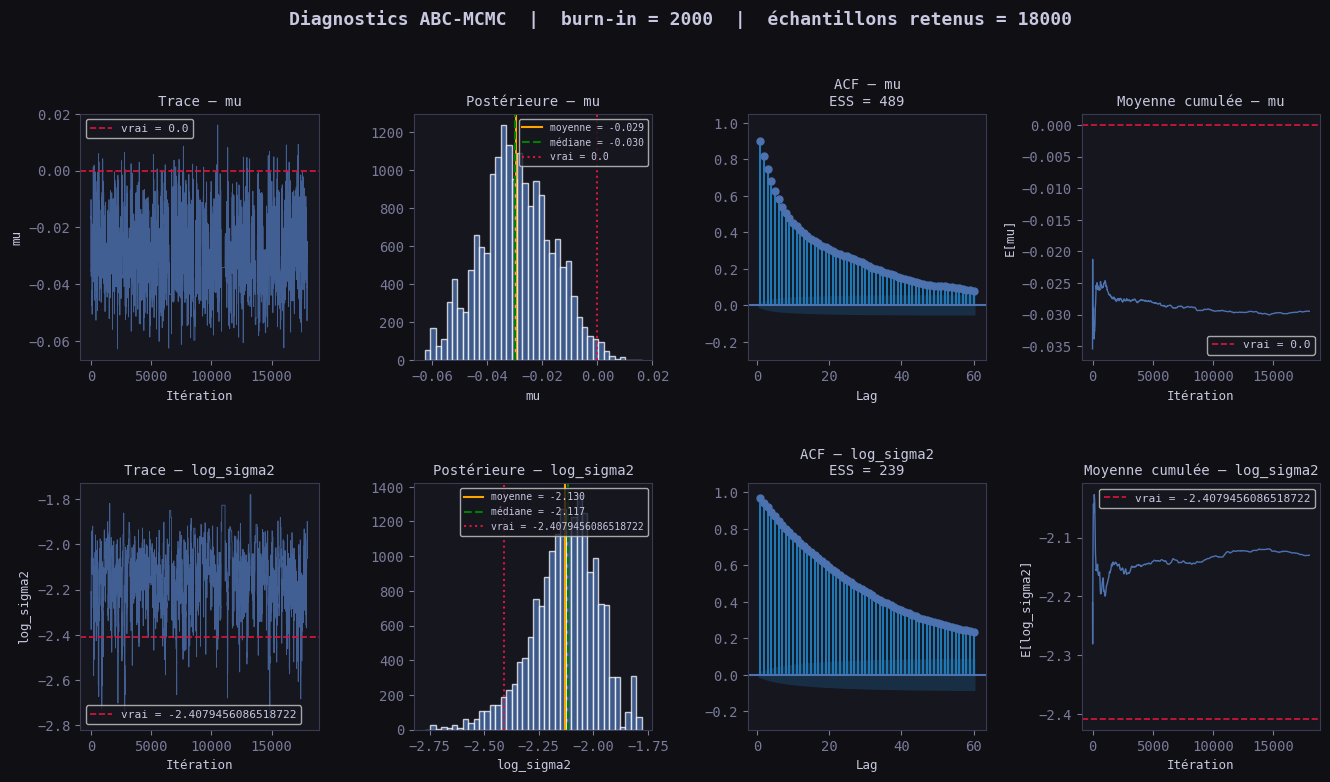

Figure sauvegardée : diagnostics_abcmcmc.png


In [6]:
import numpy as np
from q1 import simulate_lognormal_sum
from ABCMCMC_bis import ABCMCMC
from Figures import plot_diagnostics, print_summary

# Paramètres du modèle vrai
L_true = 10
mu_true = 0.0
sigma_true = 0.3
n_obs = 200

# Générer les données observées
main_rng = np.random.default_rng(42)
Y_obs = simulate_lognormal_sum(n_obs, L_true, mu_true, sigma_true, rng=main_rng)
print(f"Y_obs mean: {np.mean(Y_obs):.4f}")

# Paramètres ABC-MCMC
epsilon_val = 0.18
step_mu = 0.02
step_log_sigma = 0.1

# Lancer ABC-MCMC
print("\n=== Lancement ABC-MCMC ===")
chain, acc_rate = ABCMCMC(
    Y_obs,           # 1er argument
    L_true,          # 2ème argument  
    2.0,             # a (3ème argument)
    1.0,             # b (4ème argument)
    1.0,             # kappa (5ème argument)
    epsilon_val,     # epsilon (6ème argument)
    step_mu,         # step_mu (7ème argument)
    step_log_sigma,  # step_log_sigma2 (8ème argument)
    num_samples=20000,  # Ceux-ci peuvent rester nommés
    rng=main_rng
)

print(f"Taux d'acceptation : {acc_rate:.2%}")

# Valeurs vraies pour comparaison
true_values = [mu_true, 2*np.log(sigma_true)]

# Afficher le résumé
print_summary(
    chain, 
    param_names=["mu", "log_sigma2"], 
    burnin=2000,
    true_values=true_values
)

# Afficher les diagnostics graphiques
plot_diagnostics(
    chain, 
    param_names=["mu", "log_sigma2"], 
    burnin=2000,
    true_values=true_values
)

In [7]:
import os
print("Fichiers dans le dossier courant :")
print(os.listdir('.'))

Fichiers dans le dossier courant :
['ABCMCMC.py', 'ABCMCMC_bis.py', 'abc_mcmc_sensitivity_analysis.png', 'diagnostics_abcmcmc.png', 'fig1_prior_impact.png', 'fig2_epsilon_impact.png', 'Figures.py', 'mcmc_traces.png', 'MonteCarlo.py', 'monte_carlo_error_boxplots.png', 'q1.py', 'q1_b.py', 'results_inv_gamma_prior.ipynb', 'results_normal_prior.ipynb', '__pycache__']


In [8]:
import numpy as np
from q1 import simulate_lognormal_sum
from ABCMCMC_bis import ABCMCMC

# Paramètres du modèle vrai
L_true = 10
mu_true = 0.0
sigma_true = 0.3
n_obs = 200

# Générer les données observées (avec un seed fixe)
rng_data = np.random.default_rng(42)
Y_obs = simulate_lognormal_sum(n_obs, L_true, mu_true, sigma_true, rng=rng_data)
print(f"Y_obs mean: {np.mean(Y_obs):.4f}\n")

# Paramètres ABC-MCMC
epsilon_val = 0.18
step_mu = 0.02
step_log_sigma = 0.1
num_samples = 20000
burnin = 2000

# Prior
a, b, kappa = 2.0, 1.0, 1.0

# Lancer plusieurs chaînes avec des seeds différents
seeds = [42, 100, 200, 300, 400]
chains = []
acc_rates = []

print("=== Lancement de plusieurs chaînes ===\n")
for i, seed in enumerate(seeds):
    print(f"Chaîne {i+1} (seed={seed})... ", end="")
    rng = np.random.default_rng(seed)
    
    chain, acc_rate = ABCMCMC(
        Y_obs, L_true, 
        a, b, kappa,
        epsilon_val,
        step_mu,
        step_log_sigma,
        num_samples=num_samples,
        rng=rng
    )
    
    chains.append(chain)
    acc_rates.append(acc_rate)
    print(f"Taux d'acceptation : {acc_rate:.2%}")

print("\n" + "="*70)
print("RÉSUMÉ DES CHAÎNES (après burn-in)")
print("="*70)
print(f"{'Chaîne':<10} {'Acc. Rate':<12} {'µ moyen':<12} {'log(σ²) moyen':<15}")
print("-"*70)

for i, (chain, acc) in enumerate(zip(chains, acc_rates)):
    chain_post = chain[burnin:]
    mu_mean = np.mean(chain_post[:, 0])
    logsigma2_mean = np.mean(chain_post[:, 1])
    print(f"{i+1:<10} {acc:<12.2%} {mu_mean:<12.4f} {logsigma2_mean:<15.4f}")

print("-"*70)
print(f"{'Vraie valeur':<10} {'':<12} {mu_true:<12.4f} {2*np.log(sigma_true):<15.4f}")
print("="*70)

# Calculer les statistiques sur l'ensemble des chaînes
all_mu = [np.mean(chain[burnin:, 0]) for chain in chains]
all_logsigma2 = [np.mean(chain[burnin:, 1]) for chain in chains]

print(f"\n📊 VARIABILITÉ ENTRE CHAÎNES :")
print(f"   µ        : moyenne = {np.mean(all_mu):.4f}, écart-type = {np.std(all_mu):.4f}")
print(f"   log(σ²)  : moyenne = {np.mean(all_logsigma2):.4f}, écart-type = {np.std(all_logsigma2):.4f}")

Y_obs mean: 10.2882

=== Lancement de plusieurs chaînes ===

Chaîne 1 (seed=42)... Taux d'acceptation : 19.79%
Chaîne 2 (seed=100)... Taux d'acceptation : 21.61%
Chaîne 3 (seed=200)... Taux d'acceptation : 21.52%
Chaîne 4 (seed=300)... Taux d'acceptation : 16.56%
Chaîne 5 (seed=400)... Taux d'acceptation : 19.77%

RÉSUMÉ DES CHAÎNES (après burn-in)
Chaîne     Acc. Rate    µ moyen      log(σ²) moyen  
----------------------------------------------------------------------
1          19.79%       -0.0295      -2.1300        
2          21.61%       -0.0292      -2.1454        
3          21.52%       -0.0284      -2.1474        
4          16.56%       -0.0338      -2.0919        
5          19.77%       -0.0305      -2.1277        
----------------------------------------------------------------------
Vraie valeur              0.0000       -2.4079        

📊 VARIABILITÉ ENTRE CHAÎNES :
   µ        : moyenne = -0.0303, écart-type = 0.0019
   log(σ²)  : moyenne = -2.1285, écart-type = 0.01

In [9]:
import numpy as np

# Après burn-in
chains_post = [chain[burnin:] for chain in chains]

def compute_rhat(chains_list, param_idx):
    """
    Calcule le R-hat pour un paramètre donné.
    R-hat < 1.01 : excellent
    R-hat < 1.05 : bon
    R-hat > 1.1  : problème
    """
    m = len(chains_list)  # nombre de chaînes
    n = len(chains_list[0])  # longueur de chaque chaîne
    
    # Moyennes par chaîne
    chain_means = np.array([np.mean(chain[:, param_idx]) for chain in chains_list])
    
    # Variance intra-chaîne (moyenne des variances)
    W = np.mean([np.var(chain[:, param_idx], ddof=1) for chain in chains_list])
    
    # Variance inter-chaîne
    B = n * np.var(chain_means, ddof=1)
    
    # Variance totale estimée
    var_hat = ((n - 1) / n) * W + (1 / n) * B
    
    # R-hat
    rhat = np.sqrt(var_hat / W)
    
    return rhat

# Calculer R-hat
burnin = 2000
chains_post = [chain[burnin:] for chain in chains]

rhat_mu = compute_rhat(chains_post, 0)
rhat_logsigma2 = compute_rhat(chains_post, 1)

print(f"\nR-hat (Gelman-Rubin diagnostic):")
print(f"   µ        : {rhat_mu:.4f}  {'Excellent!' if rhat_mu < 1.01 else 'Bon' if rhat_mu < 1.05 else 'Problème'}")
print(f"   log(σ²)  : {rhat_logsigma2:.4f}  {'Excellent!' if rhat_logsigma2 < 1.01 else 'Bon' if rhat_logsigma2 < 1.05 else 'Problème'}")


R-hat (Gelman-Rubin diagnostic):
   µ        : 1.0106  Bon
   log(σ²)  : 1.0095  Excellent!


Y_obs mean: 10.2882

COMPARAISON SYSTÉMATIQUE : ESS et Autocorrélation

 ε=0.15, steps=Très petit (µ=0.01, log(σ²)=0.05)
   Acc: 28.8% | ESS(µ):  268 | ESS(log σ²):  161
   Biais(µ): -0.0259 | Biais(log σ²): +0.2095

 ε=0.15, steps=Petit (baseline) (µ=0.02, log(σ²)=0.1)
   Acc: 17.7% | ESS(µ):  388 | ESS(log σ²):  199
   Biais(µ): -0.0256 | Biais(log σ²): +0.2126

 ε=0.15, steps=Moyen (µ=0.05, log(σ²)=0.2)
   Acc:  5.4% | ESS(µ):  180 | ESS(log σ²):  123
   Biais(µ): -0.0271 | Biais(log σ²): +0.2348

 ε=0.15, steps=Grand (µ=0.1, log(σ²)=0.3)
   Acc:  2.3% | ESS(µ):   85 | ESS(log σ²):   54
   Biais(µ): -0.0279 | Biais(log σ²): +0.2257

 ε=0.18, steps=Très petit (µ=0.01, log(σ²)=0.05)
   Acc: 33.4% | ESS(µ):  201 | ESS(log σ²):  100
   Biais(µ): -0.0294 | Biais(log σ²): +0.2688

 ε=0.18, steps=Petit (baseline) (µ=0.02, log(σ²)=0.1)
   Acc: 21.0% | ESS(µ):  499 | ESS(log σ²):  300
   Biais(µ): -0.0295 | Biais(log σ²): +0.2641

 ε=0.18, steps=Moyen (µ=0.05, log(σ²)=0.2)
   Acc:  7.7% | ES

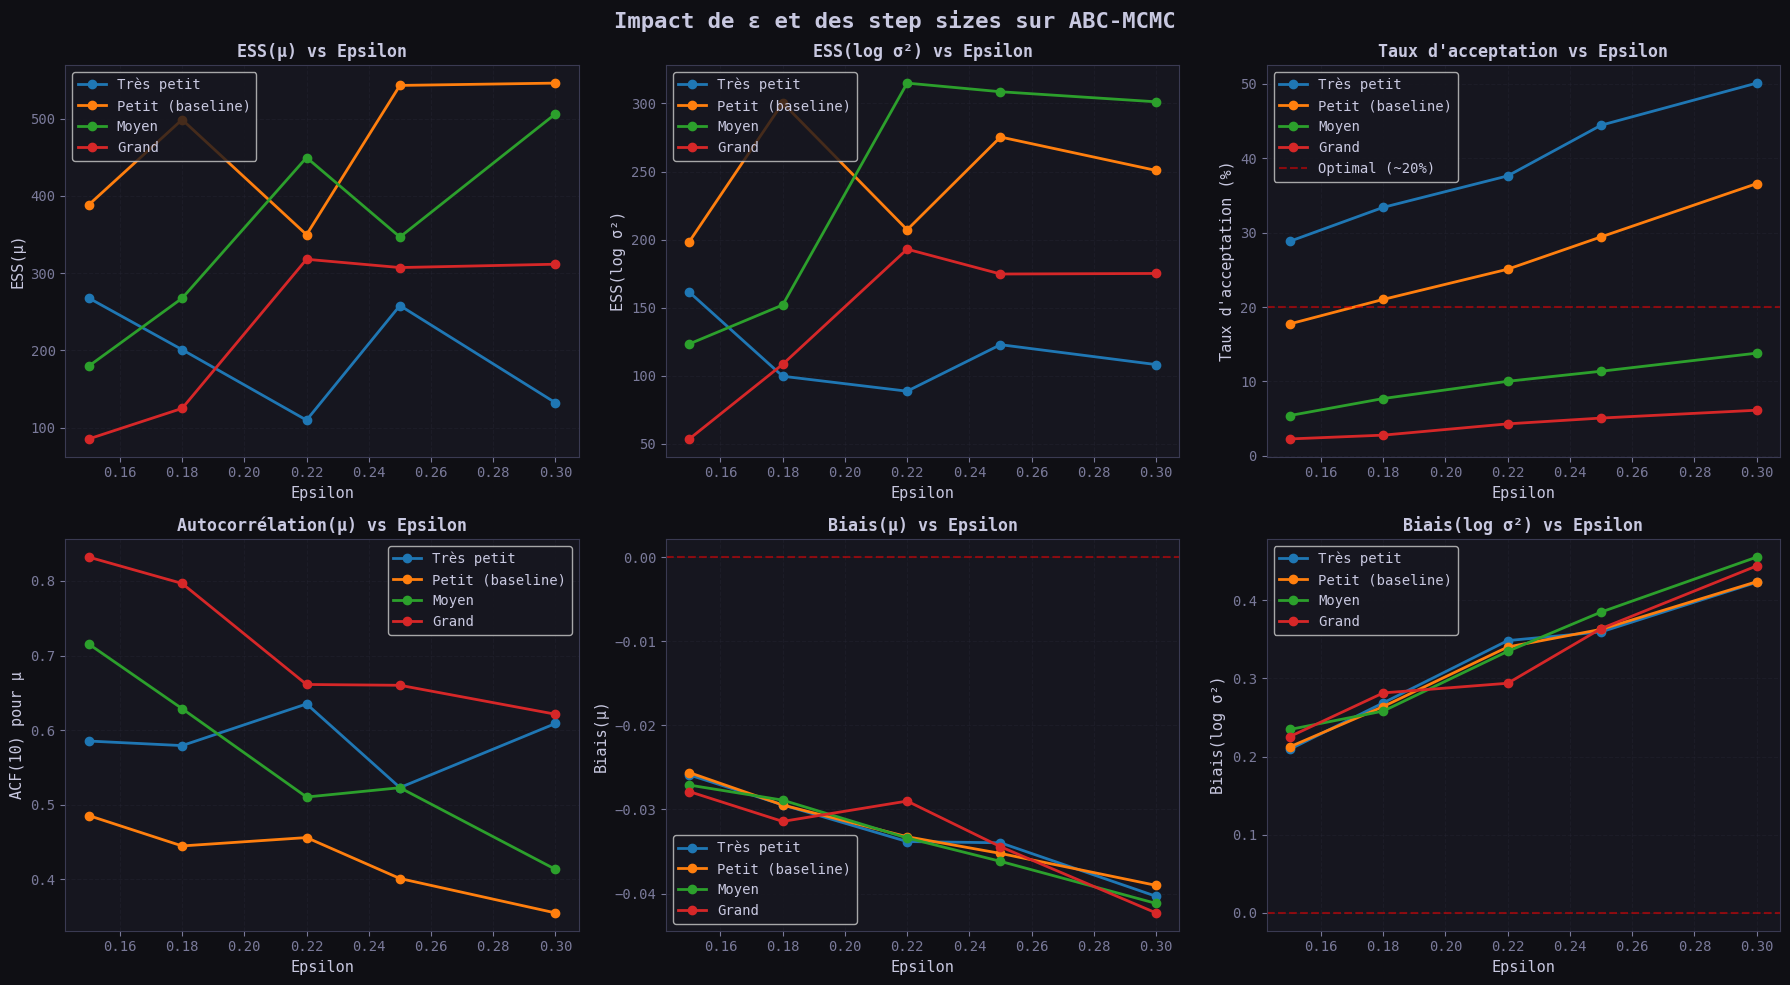


✅ Figure sauvegardée : abc_mcmc_sensitivity_analysis.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from q1 import simulate_lognormal_sum
from ABCMCMC_bis import ABCMCMC
from Figures import effective_sample_size

# Paramètres du modèle vrai
L_true = 10
mu_true = 0.0
sigma_true = 0.3
n_obs = 200

# Générer les données observées (seed fixe pour comparaison équitable)
rng_data = np.random.default_rng(42)
Y_obs = simulate_lognormal_sum(n_obs, L_true, mu_true, sigma_true, rng=rng_data)
print(f"Y_obs mean: {np.mean(Y_obs):.4f}\n")

# === GRILLE DE PARAMÈTRES À TESTER ===

# Variation de epsilon
epsilons = [0.15, 0.18, 0.22, 0.25, 0.30]

# Variation des step sizes
step_configs = [
    {"step_mu": 0.01, "step_log_sigma": 0.05, "name": "Très petit"},
    {"step_mu": 0.02, "step_log_sigma": 0.10, "name": "Petit (baseline)"},
    {"step_mu": 0.05, "step_log_sigma": 0.20, "name": "Moyen"},
    {"step_mu": 0.10, "step_log_sigma": 0.30, "name": "Grand"},
]

# Paramètres MCMC
num_samples = 20000
burnin = 2000
a, b, kappa = 2.0, 1.0, 1.0

# === BOUCLE DE TESTS ===

results = []

print("="*80)
print("COMPARAISON SYSTÉMATIQUE : ESS et Autocorrélation")
print("="*80)

for eps in epsilons:
    for step_config in step_configs:
        step_mu = step_config["step_mu"]
        step_log_sigma = step_config["step_log_sigma"]
        name = step_config["name"]
        
        print(f"\n ε={eps:.2f}, steps={name} (µ={step_mu}, log(σ²)={step_log_sigma})")
        
        # Lancer ABC-MCMC avec un seed unique
        rng = np.random.default_rng(int(eps*1000 + step_mu*10000))
        
        chain, acc_rate = ABCMCMC(
            Y_obs, L_true, a, b, kappa,
            epsilon=eps,
            step_mu=step_mu,
            step_log_sigma2=step_log_sigma,
            num_samples=num_samples,
            rng=rng
        )
        
        # Calculs post burn-in
        chain_post = chain[burnin:]
        
        # ESS
        ess_mu = effective_sample_size(chain_post[:, 0])
        ess_logsigma2 = effective_sample_size(chain_post[:, 1])
        
        # Autocorrélation au lag 10
        from statsmodels.tsa.stattools import acf
        acf_mu = acf(chain_post[:, 0], nlags=10, fft=True)[10]
        acf_logsigma2 = acf(chain_post[:, 1], nlags=10, fft=True)[10]
        
        # Estimations
        mu_mean = np.mean(chain_post[:, 0])
        logsigma2_mean = np.mean(chain_post[:, 1])
        
        # Biais
        bias_mu = mu_mean - mu_true
        bias_logsigma2 = logsigma2_mean - 2*np.log(sigma_true)
        
        print(f"   Acc: {acc_rate:5.1%} | ESS(µ): {ess_mu:4.0f} | ESS(log σ²): {ess_logsigma2:4.0f}")
        print(f"   Biais(µ): {bias_mu:+.4f} | Biais(log σ²): {bias_logsigma2:+.4f}")
        
        # Stocker les résultats
        results.append({
            'epsilon': eps,
            'step_name': name,
            'step_mu': step_mu,
            'step_log_sigma': step_log_sigma,
            'acc_rate': acc_rate,
            'ess_mu': ess_mu,
            'ess_logsigma2': ess_logsigma2,
            'acf10_mu': acf_mu,
            'acf10_logsigma2': acf_logsigma2,
            'bias_mu': bias_mu,
            'bias_logsigma2': bias_logsigma2,
            'mu_mean': mu_mean,
            'logsigma2_mean': logsigma2_mean
        })

# === CRÉATION DU DATAFRAME ===

df = pd.DataFrame(results)
print("\n" + "="*80)
print("TABLEAU RÉCAPITULATIF")
print("="*80)
print(df.to_string(index=False))

# === VISUALISATIONS ===

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Impact de ε et des step sizes sur ABC-MCMC", fontsize=16, fontweight='bold')

# 1. ESS(µ) en fonction de epsilon (groupé par step size)
ax = axes[0, 0]
for step_name in df['step_name'].unique():
    subset = df[df['step_name'] == step_name]
    ax.plot(subset['epsilon'], subset['ess_mu'], marker='o', label=step_name, linewidth=2)
ax.set_xlabel('Epsilon', fontsize=11)
ax.set_ylabel('ESS(µ)', fontsize=11)
ax.set_title('ESS(µ) vs Epsilon', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 2. ESS(log σ²) en fonction de epsilon
ax = axes[0, 1]
for step_name in df['step_name'].unique():
    subset = df[df['step_name'] == step_name]
    ax.plot(subset['epsilon'], subset['ess_logsigma2'], marker='o', label=step_name, linewidth=2)
ax.set_xlabel('Epsilon', fontsize=11)
ax.set_ylabel('ESS(log σ²)', fontsize=11)
ax.set_title('ESS(log σ²) vs Epsilon', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 3. Taux d'acceptation vs epsilon
ax = axes[0, 2]
for step_name in df['step_name'].unique():
    subset = df[df['step_name'] == step_name]
    ax.plot(subset['epsilon'], subset['acc_rate']*100, marker='o', label=step_name, linewidth=2)
ax.set_xlabel('Epsilon', fontsize=11)
ax.set_ylabel('Taux d\'acceptation (%)', fontsize=11)
ax.set_title('Taux d\'acceptation vs Epsilon', fontsize=12, fontweight='bold')
ax.axhline(20, color='red', linestyle='--', alpha=0.5, label='Optimal (~20%)')
ax.legend()
ax.grid(alpha=0.3)

# 4. Autocorrélation(µ) au lag 10
ax = axes[1, 0]
for step_name in df['step_name'].unique():
    subset = df[df['step_name'] == step_name]
    ax.plot(subset['epsilon'], subset['acf10_mu'], marker='o', label=step_name, linewidth=2)
ax.set_xlabel('Epsilon', fontsize=11)
ax.set_ylabel('ACF(10) pour µ', fontsize=11)
ax.set_title('Autocorrélation(µ) vs Epsilon', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 5. Biais(µ)
ax = axes[1, 1]
for step_name in df['step_name'].unique():
    subset = df[df['step_name'] == step_name]
    ax.plot(subset['epsilon'], subset['bias_mu'], marker='o', label=step_name, linewidth=2)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Epsilon', fontsize=11)
ax.set_ylabel('Biais(µ)', fontsize=11)
ax.set_title('Biais(µ) vs Epsilon', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 6. Biais(log σ²)
ax = axes[1, 2]
for step_name in df['step_name'].unique():
    subset = df[df['step_name'] == step_name]
    ax.plot(subset['epsilon'], subset['bias_logsigma2'], marker='o', label=step_name, linewidth=2)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Epsilon', fontsize=11)
ax.set_ylabel('Biais(log σ²)', fontsize=11)
ax.set_title('Biais(log σ²) vs Epsilon', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('abc_mcmc_sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Figure sauvegardée : abc_mcmc_sensitivity_analysis.png")

Prior utilisé : σ² ~ IG(2.0, 0.2), µ|σ² ~ N(0, 1.0σ²)
  Moyenne du prior sur σ² : 0.2000
  Écart-type du prior sur σ : 0.4472

Lancement de l'évaluation de l'erreur Monte Carlo sur 30 exécutions...
Données observées : moyenne=10.2882, std=0.9853

  → Exécution 5/30 terminée.
  → Exécution 10/30 terminée.
  → Exécution 15/30 terminée.
  → Exécution 20/30 terminée.
  → Exécution 25/30 terminée.
  → Exécution 30/30 terminée.

✓ 30 exécutions terminées.
  Reject-ABC : 30 runs avec échantillons acceptés
  MCMC-ABC   : 30 runs réussis

STATISTIQUES SUR LES ESTIMATEURS

REJECT-ABC :
  µ̂ : moyenne=-0.0164, std=0.0058, biais=-0.0164
  σ̂ : moyenne=0.2934, std=0.0129, biais=-0.0066

MCMC-ABC :
  µ̂ : moyenne=-0.0215, std=0.0124, biais=-0.0215
  σ̂ : moyenne=0.3059, std=0.0416, biais=+0.0059


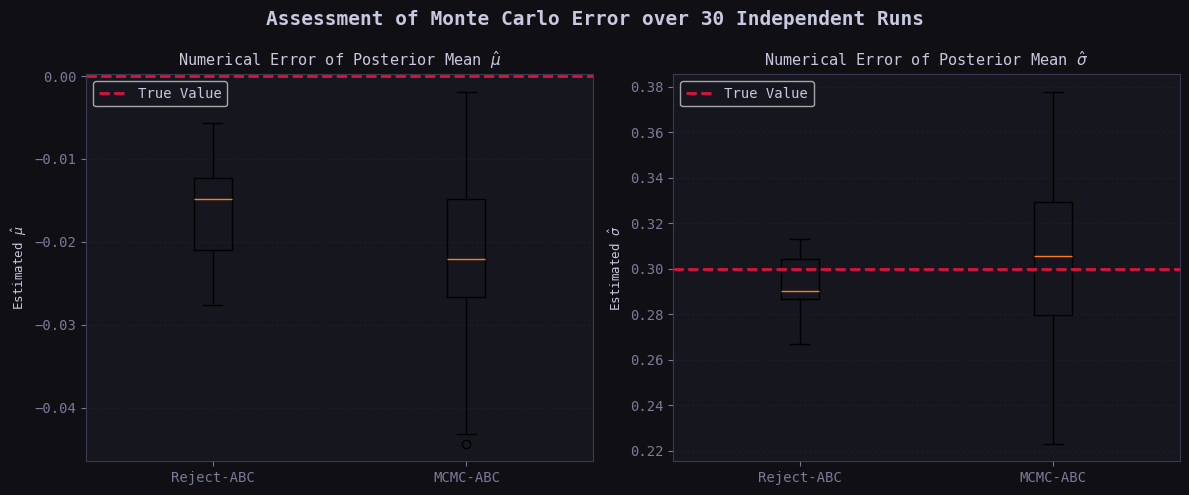


✓ Figure sauvegardée : monte_carlo_error_boxplots.png


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Importation des modules du projet
from q1_b import simulate_lognormal_sum, reject_abc
from ABCMCMC_bis import ABCMCMC

# =============================================================================
# OBJECTIF : Évaluation de l'Erreur Standard de Monte Carlo (MCSE)
# Afin de mesurer la stabilité numérique des estimateurs (variance algorithmique),
# nous exécutons plusieurs itérations indépendantes des algorithmes Reject-ABC 
# et MCMC-ABC sur un jeu de données strictement identique.
# =============================================================================

# 1. Initialisation des paramètres de l'expérience
L_true, mu_true, sigma_true, n_obs = 10, 0.0, 0.3, 200
epsilon_val = 0.5
n_runs = 30  # Nombre d'exécutions indépendantes

# ═══════════════════════════════════════════════════════════════
# NOUVEAU : Paramètres du prior conjugué
# ═══════════════════════════════════════════════════════════════
# Prior : σ² ~ IG(a, b) et µ|σ² ~ N(0, κσ²)
a_prior = 2.0      # Shape parameter de l'Inverse-Gamma
b_prior = 0.2      # Scale parameter de l'Inverse-Gamma
kappa_prior = 1.0  # Scaling factor du prior conditionnel sur µ

print(f"Prior utilisé : σ² ~ IG({a_prior}, {b_prior}), µ|σ² ~ N(0, {kappa_prior}σ²)")
print(f"  Moyenne du prior sur σ² : {b_prior/(a_prior-1):.4f}")
print(f"  Écart-type du prior sur σ : {np.sqrt(b_prior/(a_prior-1)):.4f}")
print()

# Listes de stockage pour les moyennes a posteriori estimées
mu_estimates_rej, sigma_estimates_rej = [], []
mu_estimates_mcmc, sigma_estimates_mcmc = [], []

print(f"Lancement de l'évaluation de l'erreur Monte Carlo sur {n_runs} exécutions...")

for i in range(n_runs):
    # Isolation de l'état aléatoire pour garantir l'indépendance de chaque exécution
    rng_run = np.random.default_rng(1000 + i)
    
    # 2. Fixation des observations empiriques (Y_obs)
    # Pour isoler l'erreur Monte Carlo de l'erreur d'échantillonnage des données, 
    # le jeu de données cible n'est généré qu'une seule fois.
    if i == 0:
        rng_data = np.random.default_rng(42)
        Y_obs_fixed = simulate_lognormal_sum(n_obs, L_true, mu_true, sigma_true, rng=rng_data)
        print(f"Données observées : moyenne={np.mean(Y_obs_fixed):.4f}, std={np.std(Y_obs_fixed):.4f}\n")
    
    # --- 3. Exécution du Rejection-ABC ---
    # MODIFIÉ : Utilisation du nouveau prior IG(a,b) et N(0, κσ²)
    samples_rej, _ = reject_abc(
        Y_obs_fixed, L_true, 
        a=a_prior, b=b_prior, kappa=kappa_prior,  # ← NOUVEAU
        epsilon=epsilon_val, 
        num_samples=50, 
        max_attempts=50000,
        rng=rng_run
    )
    
    if len(samples_rej) > 0:
        mu_estimates_rej.append(np.mean(samples_rej[:, 0]))
        sigma_estimates_rej.append(np.mean(samples_rej[:, 1]))  # La colonne 1 contient sigma
    else:
        print(f"  ⚠ Run {i+1}: Reject-ABC n'a accepté aucun échantillon !")

    # --- 4. Exécution du MCMC-ABC ---
    # MODIFIÉ : Utilisation du nouveau prior
    chain_mcmc, _ = ABCMCMC(
        Y_obs_fixed, L_true, 
        a=a_prior, b=b_prior, kappa=kappa_prior,  # ← NOUVEAU
        epsilon=epsilon_val, 
        step_mu=0.05, 
        step_log_sigma2=0.05, 
        num_samples=2000, 
        rng=rng_run
    )
    
    # Traitement post-échantillonnage : exclusion du burn-in
    burnin = 400
    post_burnin_chain = chain_mcmc[burnin:]
    
    # Stockage de l'estimation de mu
    mu_estimates_mcmc.append(np.mean(post_burnin_chain[:, 0]))
    
    # Stockage de l'estimation de sigma
    # Note : La colonne 1 de MCMC-ABC contient log(sigma^2). On le transforme en sigma.
    sigma_mcmc_samples = np.exp(0.5 * post_burnin_chain[:, 1])  # ← MODIFIÉ : simplifié
    sigma_estimates_mcmc.append(np.mean(sigma_mcmc_samples))
    
    if (i + 1) % 5 == 0:
        print(f"  → Exécution {i + 1}/{n_runs} terminée.")

print(f"\n✓ {n_runs} exécutions terminées.")
print(f"  Reject-ABC : {len(mu_estimates_rej)} runs avec échantillons acceptés")
print(f"  MCMC-ABC   : {len(mu_estimates_mcmc)} runs réussis")

# =============================================================================
# 5. Statistiques descriptives
# =============================================================================
print("\n" + "="*70)
print("STATISTIQUES SUR LES ESTIMATEURS")
print("="*70)

print("\nREJECT-ABC :")
print(f"  µ̂ : moyenne={np.mean(mu_estimates_rej):.4f}, std={np.std(mu_estimates_rej):.4f}, biais={np.mean(mu_estimates_rej) - mu_true:+.4f}")
print(f"  σ̂ : moyenne={np.mean(sigma_estimates_rej):.4f}, std={np.std(sigma_estimates_rej):.4f}, biais={np.mean(sigma_estimates_rej) - sigma_true:+.4f}")

print("\nMCMC-ABC :")
print(f"  µ̂ : moyenne={np.mean(mu_estimates_mcmc):.4f}, std={np.std(mu_estimates_mcmc):.4f}, biais={np.mean(mu_estimates_mcmc) - mu_true:+.4f}")
print(f"  σ̂ : moyenne={np.mean(sigma_estimates_mcmc):.4f}, std={np.std(sigma_estimates_mcmc):.4f}, biais={np.mean(sigma_estimates_mcmc) - sigma_true:+.4f}")

# =============================================================================
# 6. Visualisation : Comparaison de la variance algorithmique (Box-plots)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique de la distribution des estimateurs pour mu
axes[0].boxplot([mu_estimates_rej, mu_estimates_mcmc], tick_labels=['Reject-ABC', 'MCMC-ABC'])
axes[0].axhline(mu_true, color='crimson', linestyle='--', linewidth=2, label='True Value')
axes[0].set_title(r"Numerical Error of Posterior Mean $\hat{\mu}$", fontsize=11)
axes[0].set_ylabel(r"Estimated $\hat{\mu}$")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Graphique de la distribution des estimateurs pour sigma
axes[1].boxplot([sigma_estimates_rej, sigma_estimates_mcmc], tick_labels=['Reject-ABC', 'MCMC-ABC'])
axes[1].axhline(sigma_true, color='crimson', linestyle='--', linewidth=2, label='True Value')
axes[1].set_title(r"Numerical Error of Posterior Mean $\hat{\sigma}$", fontsize=11)
axes[1].set_ylabel(r"Estimated $\hat{\sigma}$")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(f"Assessment of Monte Carlo Error over {n_runs} Independent Runs", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("monte_carlo_error_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✓ Figure sauvegardée : monte_carlo_error_boxplots.png")

## Questions 3 & 4

In [12]:
# Dans une cellule de votre notebook
%run MonteCarlo.py

Iter 1000/10000, Acc rate: 0.427


KeyboardInterrupt: 

In [ ]:
"""
Compléter la Q4 après exécution de MonteCarlo.py
"""

# ═══════════════════════════════════════════════════════════════
# PARTIE 1 : Exécuter MonteCarlo.py (Q3 + partie de Q4)
# ═══════════════════════════════════════════════════════════════

%run MonteCarlo.py

# À ce stade vous avez :
# - mu_exact, sigma_exact (Gibbs)
# - Résultats Reject-ABC pour plusieurs epsilon
# - Y_obs, L, n (variables globales)

print("\n✓ MonteCarlo.py exécuté")
print(f"  Gibbs → µ̂={mu_exact:.4f}, σ̂={sigma_exact:.4f}")

# ═══════════════════════════════════════════════════════════════
# PARTIE 2 : Ajouter ABC-MCMC pour compléter Q4
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("COMPLÉTION Q4 : Ajout ABC-MCMC")
print("="*70)

from ABCMCMC_bis import ABCMCMC
from Figures import effective_sample_size
import time

# Paramètres
a, b, kappa = 2.0, 0.2, 1.0
eps_comparison = 0.5  # Choisir un epsilon pour la comparaison

# 1. Reject-ABC (déjà fait dans MonteCarlo, mais relancer pour ε=0.5)
print("\n1. REJECT-ABC")
start = time.time()
mean_mu_reject, mean_sigma_reject, acc_reject = abc_rejection(eps_comparison, 10000)
time_reject = time.time() - start
bias_mu_reject = mean_mu_reject - mu_exact
bias_sigma_reject = mean_sigma_reject - sigma_exact

print(f"   Temps : {time_reject:.1f}s")
print(f"   Acc : {acc_reject:.2%}")
print(f"   µ̂ = {mean_mu_reject:.4f} (biais={bias_mu_reject:+.4f})")
print(f"   σ̂ = {mean_sigma_reject:.4f} (biais={bias_sigma_reject:+.4f})")

# 2. ABC-MCMC
print("\n2. ABC-MCMC")
start = time.time()
results_mcmc = ABCMCMC(
    Y_obs, L, a, b, kappa,
    epsilon=eps_comparison,
    step_mu=0.02,
    step_log_sigma2=0.1,
    num_samples=20000,
    rng=np.random.default_rng(42)
)
time_mcmc = time.time() - start

chain = results_mcmc['chain'][2000:]  # burn-in
mu_mcmc = np.mean(chain[:, 0])
sigma_mcmc = np.mean(np.exp(0.5 * chain[:, 1]))
bias_mu_mcmc = mu_mcmc - mu_exact
bias_sigma_mcmc = sigma_mcmc - sigma_exact

ess_mu = effective_sample_size(chain[:, 0])
ess_sigma = effective_sample_size(np.exp(0.5 * chain[:, 1]))

print(f"   Temps : {time_mcmc:.1f}s")
print(f"   Acc : {results_mcmc['acc_rate']:.2%}")
print(f"   µ̂ = {mu_mcmc:.4f} (biais={bias_mu_mcmc:+.4f}, ESS={ess_mu:.0f})")
print(f"   σ̂ = {sigma_mcmc:.4f} (biais={bias_sigma_mcmc:+.4f}, ESS={ess_sigma:.0f})")

# 3. Tableau comparatif
print("\n" + "="*70)
print("TABLEAU COMPARATIF FINAL (Q4)")
print("="*70)

import pandas as pd

df = pd.DataFrame({
    'Méthode': ['Gibbs (Exact)', 'Reject-ABC', 'ABC-MCMC'],
    'µ̂': [mu_exact, mean_mu_reject, mu_mcmc],
    'Biais(µ)': [0, bias_mu_reject, bias_mu_mcmc],
    'σ̂': [sigma_exact, mean_sigma_reject, sigma_mcmc],
    'Biais(σ)': [0, bias_sigma_reject, bias_sigma_mcmc],
    'Temps (s)': ['~' + str(int(time.time() - start_time)), f"{time_reject:.1f}", f"{time_mcmc:.1f}"]
})

print(df.to_string(index=False))